In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB,GaussianNB, BernoulliNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

In [2]:
df = pd.read_csv(r"/Users/siddhu/Desktop/Programs/Machine Learning/Ex4/FlavorSense.csv")
print(df.head())

    age sleep_cycle exercise_habits climate_zone historical_cuisine_exposure  \
0  56.0   Irregular           Heavy    Temperate                         NaN   
1   NaN   Night Owl           Heavy    Temperate                       Asian   
2  46.0   Night Owl           Heavy         Cold                       Mixed   
3  32.0  Early Bird           Heavy         Cold               Mediterranean   
4  60.0   Night Owl        Moderate          Dry               Mediterranean   

  preferred_taste  
0           Salty  
1           Sweet  
2            Sour  
3           Salty  
4            Sour  


In [3]:
print(df.isnull().sum())

age                            968
sleep_cycle                    684
exercise_habits                804
climate_zone                   533
historical_cuisine_exposure    654
preferred_taste                  0
dtype: int64


In [4]:
df['age'].fillna(df['age'].median(), inplace=True)

categorical_cols = ['sleep_cycle','exercise_habits','climate_zone','historical_cuisine_exposure']
for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

/var/folders/vt/y6d48g2s7cg7csds0384wh400000gn/T/ipykernel_14280/3553590000.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)
/var/folders/vt/y6d48g2s7cg7csds0384wh400000gn/T/ipykernel_14280/3553590000.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values al

In [5]:
print(df.isnull().sum())

age                            0
sleep_cycle                    0
exercise_habits                0
climate_zone                   0
historical_cuisine_exposure    0
preferred_taste                0
dtype: int64


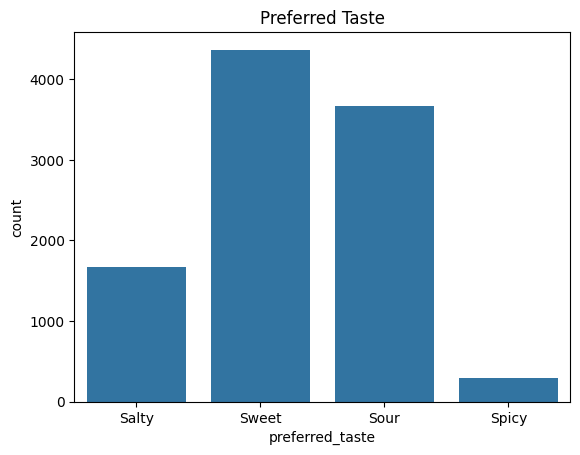

In [6]:
df['preferred_taste'].value_counts()
df['preferred_taste'].value_counts(normalize=True) * 100
sns.countplot(x='preferred_taste', data=df)
plt.title('Preferred Taste')
plt.show()

Number of outiers in 'age' : 0
Empty DataFrame
Columns: [age]
Index: []


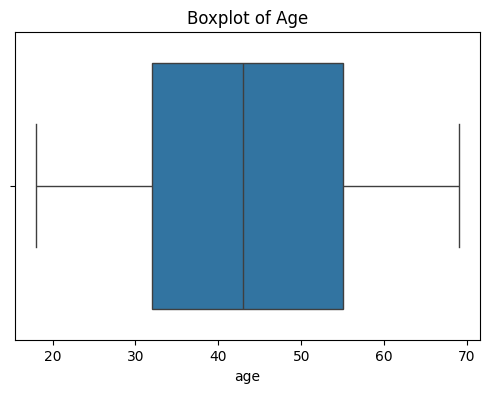

In [7]:
z_scores = stats.zscore(df['age'])
outliers = df[np.abs(z_scores)>3]
print("Number of outiers in 'age' :",outliers.shape[0])
print(outliers[['age']])

plt.figure(figsize=(6,4))
sns.boxplot(x=df['age'])
plt.title("Boxplot of Age")
plt.show()

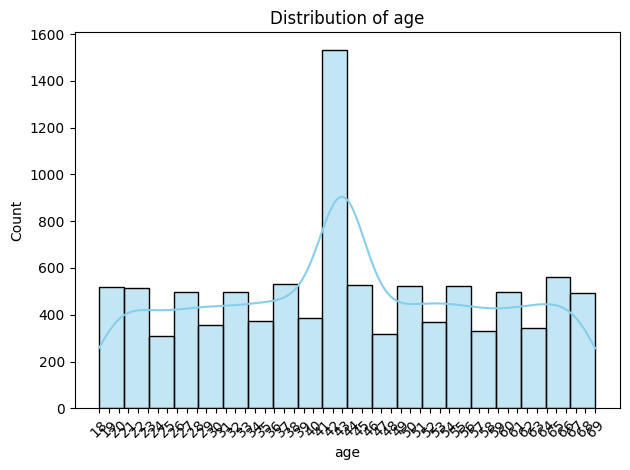

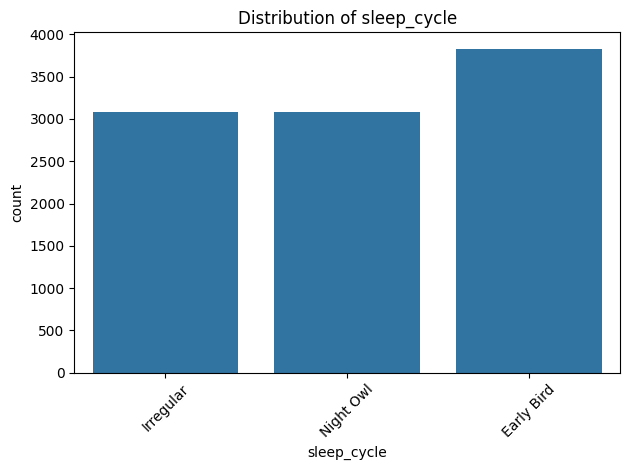

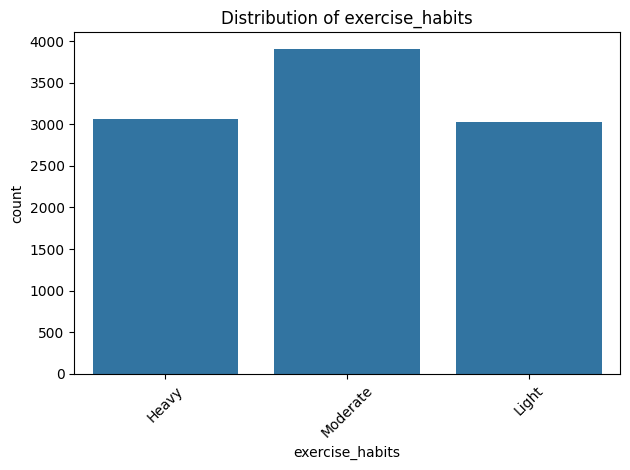

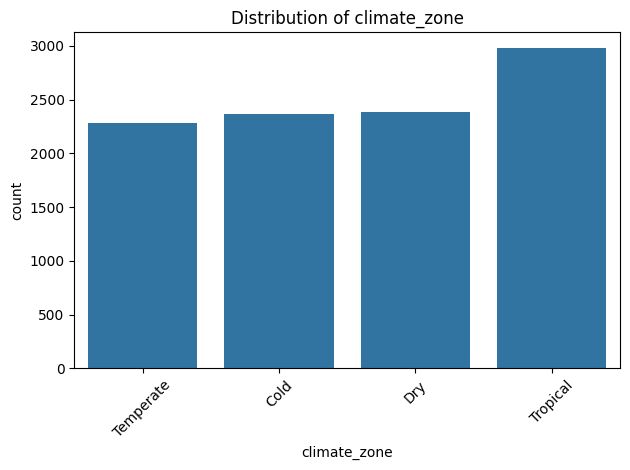

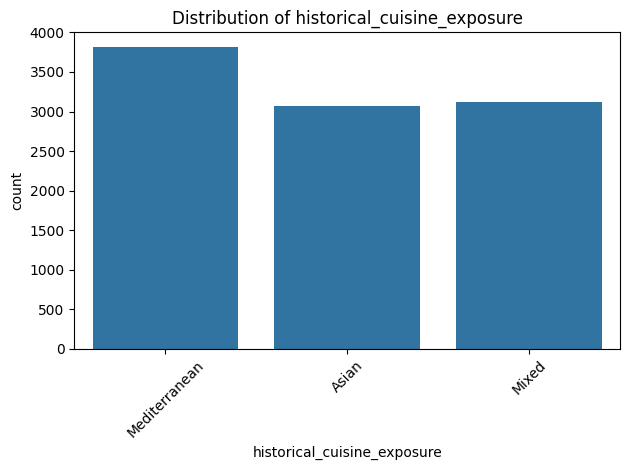

In [8]:
for col in df.columns[:-1]:
    if df[col].dtype == 'object':
        sns.countplot(data=df, x=col)
    else:
        sns.histplot(data=df, x=col, kde=True, bins=20, color='skyblue')
        plt.xticks(ticks=np.arange(df[col].min(), df[col].max()+1, step=1))
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


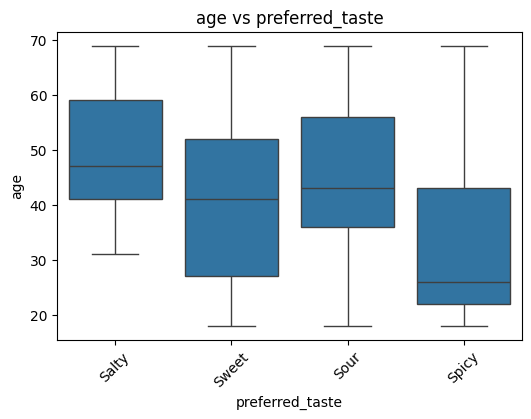

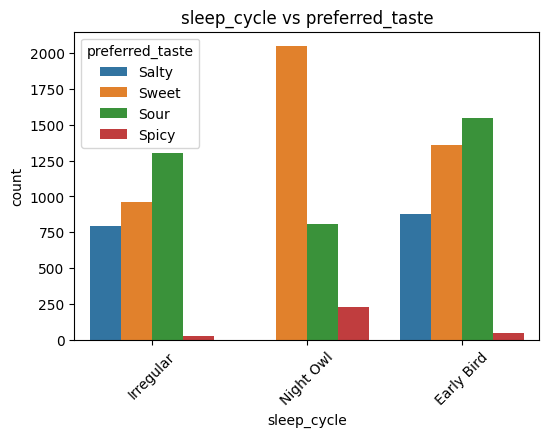

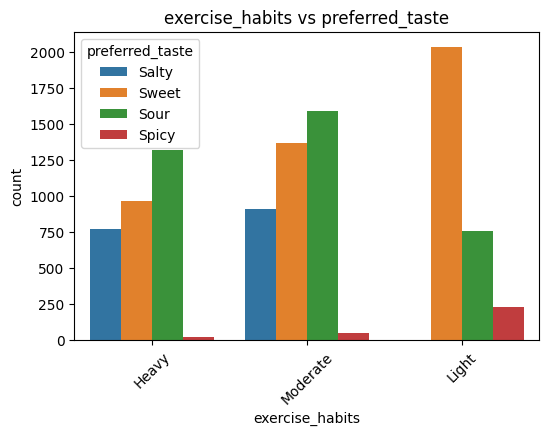

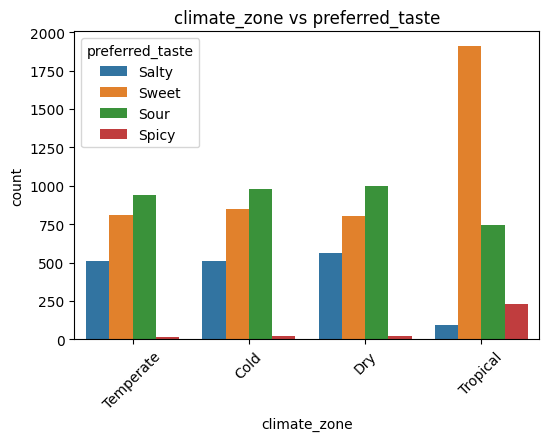

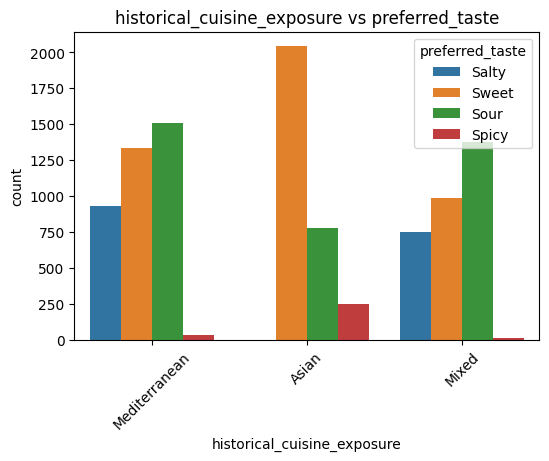

In [9]:
for col in df.columns[:-1]:
    plt.figure(figsize=(6, 4))
    if df[col].dtype == 'object':
        sns.countplot(data=df, x=col, hue='preferred_taste')
    else:
        sns.boxplot(data=df, x='preferred_taste', y=col)
    plt.title(f"{col} vs preferred_taste")
    plt.xticks(rotation=45)
    plt.show()

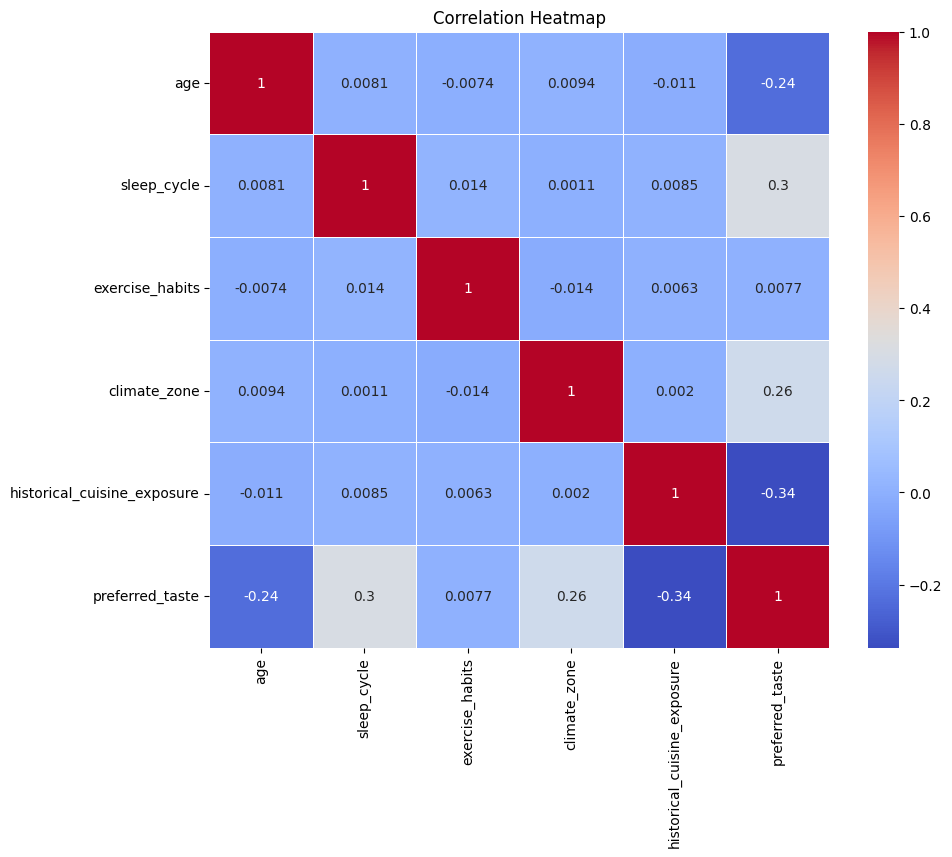

In [10]:
df_encoded = df.copy()
label_encoders = {}

for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object' or str(df_encoded[col].dtype) == 'category':
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col])
        label_encoders[col] = le
plt.figure(figsize=(10,8))
sns.heatmap(df_encoded.corr(),annot = True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()




In [11]:
X = df_encoded.drop('preferred_taste', axis=1)
y = df_encoded['preferred_taste']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Accuracy: 0.635

Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.36      0.46       339
           1       0.55      0.61      0.58       741
           2       1.00      0.03      0.06        65
           3       0.70      0.81      0.75       855

    accuracy                           0.64      2000
   macro avg       0.72      0.45      0.46      2000
weighted avg       0.65      0.64      0.62      2000



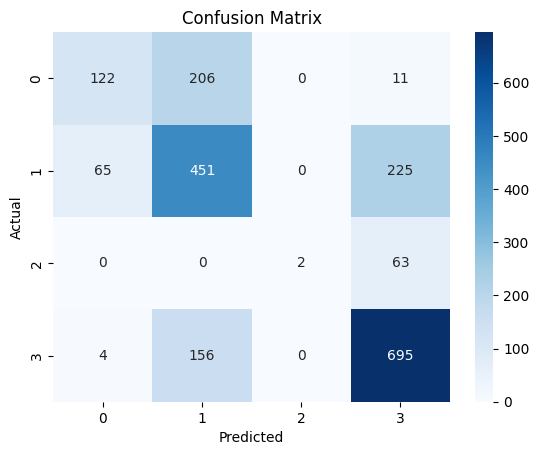

In [12]:
model = GaussianNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Step 8: Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Step 9: Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [13]:
from sklearn.preprocessing import OneHotEncoder

# Separate features and target
X = df.drop('preferred_taste', axis=1)
y = df['preferred_taste']

X_encoded = pd.get_dummies(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)



Accuracy: 0.783

Classification Report:
               precision    recall  f1-score   support

       Salty       0.82      0.83      0.83       339
        Sour       0.74      0.78      0.76       741
       Spicy       0.00      0.00      0.00        65
       Sweet       0.81      0.83      0.82       855

    accuracy                           0.78      2000
   macro avg       0.59      0.61      0.60      2000
weighted avg       0.76      0.78      0.77      2000



/Users/siddhu/Desktop/Programs/Machine Learning/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/siddhu/Desktop/Programs/Machine Learning/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/siddhu/Desktop/Programs/Machine Learning/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this 

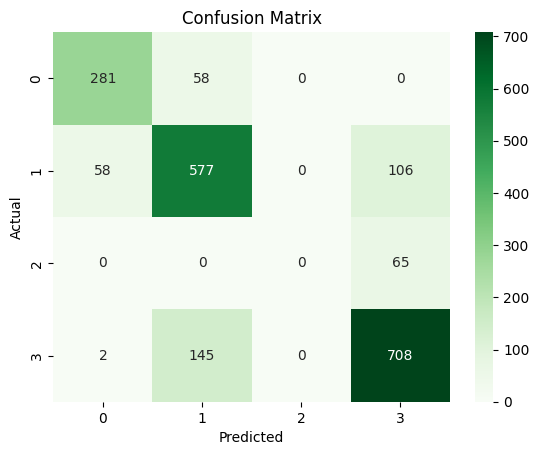

In [14]:
gnb_model = MultinomialNB()
gnb_model.fit(X_train, y_train)
gnb_pred = gnb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, gnb_pred))
print("\nClassification Report:\n", classification_report(y_test, gnb_pred))

cm_gnb = confusion_matrix(y_test, gnb_pred)
sns.heatmap(cm_gnb, annot=True, cmap='Greens', fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()



Accuracy: 0.757

Classification Report:
               precision    recall  f1-score   support

       Salty       0.68      0.95      0.79       339
        Sour       0.69      0.77      0.73       741
       Spicy       0.94      0.23      0.37        65
       Sweet       0.88      0.71      0.79       855

    accuracy                           0.76      2000
   macro avg       0.80      0.66      0.67      2000
weighted avg       0.78      0.76      0.75      2000



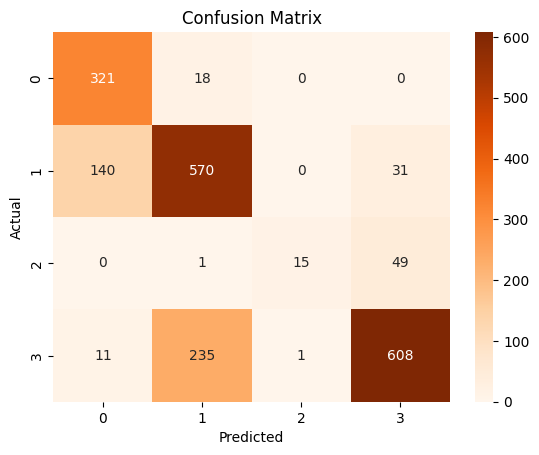

In [15]:
bnb_model = BernoulliNB()
bnb_model.fit(X_train, y_train)
bnb_pred = bnb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, bnb_pred))
print("\nClassification Report:\n", classification_report(y_test, bnb_pred))

cm_bnb = confusion_matrix(y_test, bnb_pred)
sns.heatmap(cm_bnb, annot=True, cmap='Oranges', fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
